# Atelier Préparation de Données Textuelles

 Contexte 
 
 Une entreprise souhaite développer un système capable de classer automatiquement des avis clients afin d'identifier leur sentiment. Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, réseaux sociaux et service client. Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes. Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent donc construire un pipeline complet de préparation des données textuelles. Objectifs pédagogiques À la fin de l'atelier, l'apprenant doit être capable de : 
 1) explorer un corpus textuel ; 
 2) identifier les problèmes de qualité des données ; 
 3) nettoyer les textes ; 
 4) tokeniser les textes ; 
 5) normaliser les données textuelles ; 
 6) transformer les textes en représentations numériques ; 
 7) comparer plusieurs méthodes de vectorisation ; 
 8) préparer un corpus exploitable par un modèle de ML/DL.

In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  

# Partie 1 – Exploration du corpus

## 1) Charger les données CSV

In [2]:
df = pd.read_csv("../data/smart_reviews_raw.csv")  # charge le fichier CSV

df.head() 

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...,positif,5,fr


## 2) Combien d'avis contient le dataset ?

In [3]:
print("2) Nombre d'avis :", len(df))  # nombre de lignes = nombre d'avis

2) Nombre d'avis : 1200


## 3) Combien de colonnes possède-t-il ?

In [4]:
print("3) Nombre de colonnes :", len(df.columns))  # nombre de colonnes

3) Nombre de colonnes : 8


## 4) Quel est le type de chaque colonne ?

In [5]:
print(df.dtypes)  # affiche le type de chaque colonne

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object


## 5) Existe-t-il des valeurs manquantes ?

In [6]:
print(df.isna().sum())  # compte les valeurs manquantes par colonne

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64


## 6) Identifier quelques types de texte

In [7]:
print("Texte normal :", df["texte"].iloc[3])
print("Texte vide :", df[df["texte"].str.strip() == ""]["texte"].head(1).tolist())
print("Avec URL :", df[df["texte"].str.contains("http", na=False)]["texte"].head(1).tolist())
print("Avec mention :", df[df["texte"].str.contains("@", na=False)]["texte"].head(1).tolist())
print("Avec hashtag :", df[df["texte"].str.contains("#", na=False)]["texte"].head(1).tolist())
print("Avec majuscules :", df[df["texte"].str.isupper()]["texte"].head(1).tolist())

Texte normal : Produit excellent, je suis très satisfait. !!!
Texte vide : ['   ']
Avec URL : ['Produit parfait, rien à signaler. https://example.com/commande/17']
Avec mention : ['@client Livraison rapide et produit conforme à mes attentes.']
Avec hashtag : ['Très satisfait de mon achat 👍 #avis']
Avec majuscules : ["LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."]


## 7) Mesurer la longueur des textes en créant une nouvelle colonne « longueur »

###  cree une colonne avec le nombre de caracteres de chaque texte


In [8]:
df["longueur"] = df["texte"].str.len()  # cree une colonne avec le nombre de caracteres de chaque texte


### statistiques descriciptive de la longueur

In [9]:
print("Min :", df["longueur"].min())
print("Max :", df["longueur"].max())
print("Moyenne :", df["longueur"].mean())
print("Médiane :", df["longueur"].median())
print("Quartiles :", df["longueur"].quantile([0.25, 0.5, 0.75]))

Min : 2.0
Max : 636.0
Moyenne : 49.168200836820084
Médiane : 48.0
Quartiles : 0.25    37.0
0.50    48.0
0.75    56.0
Name: longueur, dtype: float64


## 8) Visualiser la distribution de la longueur des avis

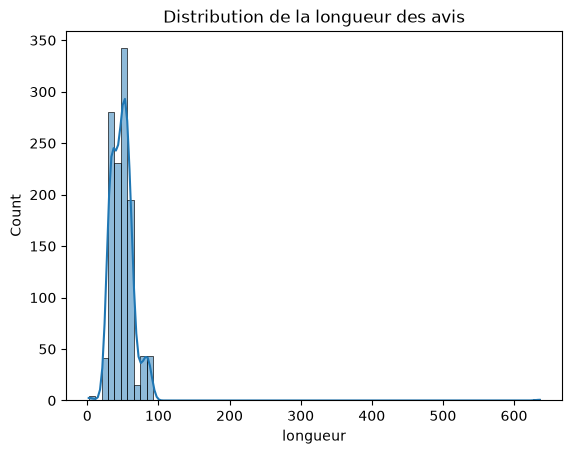

In [10]:
sns.histplot(df["longueur"].dropna(), kde=True)  # histogramme de la longueur des textes
plt.title("Distribution de la longueur des avis")
plt.show()

### a) Existe-t-il des textes anormalement longs ?


Oui — l'axe des x s'étend jusqu'à plus de 600 caractères, alors que la quasi-totalité des
avis se concentre entre 20 et 100. Cela indique la présence de quelques textes très longs,
statistiquement isolés, qui étirent l'échelle du graphique sans être visibles comme un
groupe : la masse principale
est resserrée, mais des valeurs extrêmes rares déforment l'axe).

### b) Existe-t-il beaucoup de textes très courts ?

Le pic principal se situe autour de 50-60 caractères, avec une remontée notable vers 20-30
également. Il n'y a pas de barre concentrée près de 0, donc pas une majorité de textes
"quasi vides" — mais une partie des avis reste courte (une phrase simple), cohérent avec
des avis clients typiques.

## 9) Détecter les textes vides

In [11]:
nb_vides = (df["texte"].str.strip() == "").sum()  # compte les textes reduits a rien une fois les espaces enleves
print("Textes vides :", nb_vides)

Textes vides : 1


## 10) Détecter les doublons sur le texte

In [12]:
nb_doublons = df["texte"].duplicated().sum()  # compte les textes identiques a un autre deja vu
print("Doublons :", nb_doublons)

Doublons : 881


## 11) Les classes sont-elles équilibrées ?

In [13]:
print(df["sentiment"].value_counts())

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64


non elle ne le sont pas 

## 12) Quelle est la classe majoritaire ?

In [14]:
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
positif    64.666667
neutre     20.500000
negatif    14.833333
Name: proportion, dtype: float64


la classe positif est majoritaire   avec ~64%

## 13) Quelles métriques de classification à envisager d’utiliser ?

les classes sont désequilibrées, privilégier F1-score, precision,
recall par classe plutôt que l'accuracy seule (qui serait trompeuse).

## 14) Détecter les caractères particuliers :

### Emojis

In [15]:
print("Emojis (approx) :", df["texte"].str.contains(r'[\U0001F300-\U0001FAFF]', regex=True, na=False).sum())


Emojis (approx) : 192


### URLs

In [16]:
print("URLs :", df["texte"].str.contains(r'http\S+', regex=True, na=False).sum())


URLs : 143


###  Hashtags

In [17]:
print("Hashtags :", df["texte"].str.contains(r'#\w+', regex=True, na=False).sum())


Hashtags : 127


### Mentions

In [18]:
print("Mentions :", df["texte"].str.contains(r'@\w+', regex=True, na=False).sum())


Mentions : 128


### Chiffres

In [19]:
print("Chiffres :", df["texte"].str.contains(r'\d', regex=True, na=False).sum())


Chiffres : 142


### Ponctuation repetee

In [20]:
print("Ponctuation repetee :", df["texte"].str.contains(r'([!?.])\1{1,}', regex=True, na=False).sum())

Ponctuation repetee : 141


C:\Users\DELL\AppData\Local\Temp\ipykernel_17476\2239189011.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  print("Ponctuation repetee :", df["texte"].str.contains(r'([!?.])\1{1,}', regex=True, na=False).sum())


## 15) Visualiser et commenter nombre d'avis par source

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


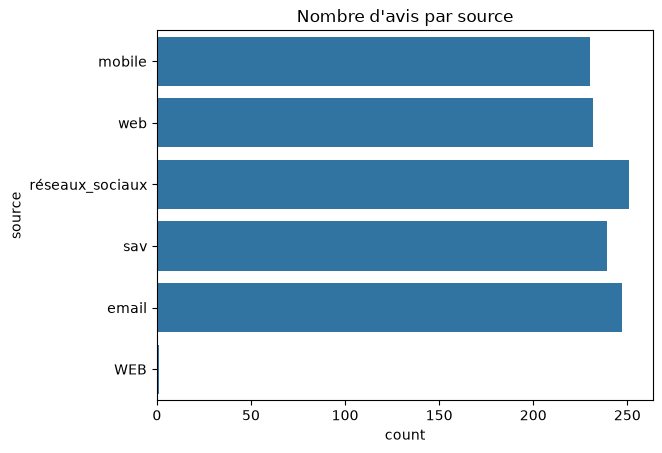

In [21]:
print(df["source"].value_counts())
sns.countplot(data=df, y="source")
plt.title("Nombre d'avis par source")
plt.show()

La répartition est équilibrée entre 5 sources réelles : réseaux_sociaux (251), email (247),
sav (239), web (232+1), mobile (230) — chacune représentant entre 19% et 21% du corpus,
sans déséquilibre notable.

**Anomalie détectée** : une ligne porte la valeur "WEB" (majuscules) au lieu de "web" —
il s'agit de la même source mal orthographiée, pas d'une 6e catégorie distincte. Cette
incohérence de casse devra être corrigée lors du nettoyage (Partie 2), par exemple avec
`df["source"] = df["source"].str.lower()`.

## 16) Visualiser et commenter le nombre d'avis par produit

produit
Écouteurs AirSound     218
Ordinateur NovaBook    217
SmartPhone X           201
SmartWatch Pro         193
Tablette TabPlus       187
SmartPhone Y           184
Name: count, dtype: int64


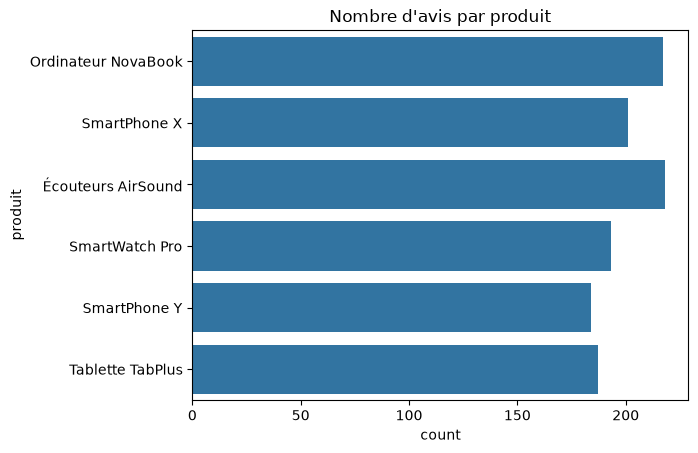

In [22]:
print(df["produit"].value_counts())
sns.countplot(data=df, y="produit")
plt.title("Nombre d'avis par produit")
plt.show()

### 16) Nombre d'avis par produit

| Produit | Nombre d'avis |
|---|---|
| Écouteurs AirSound | 218 |
| Ordinateur NovaBook | 217 |
| SmartPhone X | 201 |
| SmartWatch Pro | 193 |
| Tablette TabPlus | 187 |
| SmartPhone Y | 184 |

**Commentaire** : répartition équilibrée entre les 6 produits, chacun représentant entre
15% et 18% du corpus (184 à 218 avis). Aucun produit ne domine ni n'est sous-représenté
de façon marquée contrairement à `etat_systeme` dans l'atelier images (où "Panne"
n'avait que 2,6%), ici l'écart entre le plus et le moins représenté reste faible
(218 vs 184, soit un ratio d'environ 1,2:1 seulement).

**Point de vigilance** : SmartPhone X et SmartPhone Y sont deux produits distincts avec
des noms proches  à ne pas confondre lors d'une lecture rapide, mais ce sont bien deux
catégories différentes dans les données, pas une erreur de saisie comme "WEB"/"web".

# Partie 2 – Nettoyage


## 1) Supprimer les lignes contenant des valeurs manquantes de texte

In [24]:
print("Avant :", len(df))
df = df.dropna(subset=["texte"])
print("Après :", len(df))

Avant : 1200
Après : 1195


## 2) Supprimer les doublons

In [25]:
print("Avant :", len(df))
df = df.drop_duplicates(subset="texte")  # supprime les lignes ou le texte est identique a une ligne deja gardee
print("Après :", len(df))

Avant : 1195
Après : 318


## 3: suppression des URLs

In [26]:
import re  # expressions regulieres

df["texte"] = df["texte"].apply(lambda t: re.sub(r'http\S+|www\.\S+', '', t))  # remplace toute URL par du vide

print(df["texte"].head())  # verification visuelle

0      Très  bonne  expérience,  simple  et  efficace.
1                  Très satisfait de mon achat 👍 #avis
2                Produit  parfait,  rien  à  signaler.
3       Produit excellent, je suis très satisfait. !!!
4    LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
Name: texte, dtype: str


## 4) Traiter les mentions et hashtags avec la stratégie la plus pertinente pour une classification de
 ## sentiment

**Stratégie choisie** : pour une classification de sentiment, une mention (@client) n'apporte
aucune information sur le sentiment — on la supprime. Un hashtag peut porter du sens
(#deception, #top) : on garde le mot mais on retire le symbole #, plutôt que de tout supprimer.

In [28]:
# les mentions sont des mots precedes du caractere @, par exemple @username. On peut les supprimer avec une expression reguliere.
df["texte"] = df["texte"].apply(lambda t: re.sub(r'@\w+', '', t))  # supprime les mentions entierement


In [ ]:
# les hashtags sont des mots precedes du caractere #, par exemple #hashtag. 
df["texte"] = df["texte"].apply(lambda t: re.sub(r'#(\w+)', r'\1', t))  # garde le mot du hashtag, retire juste le #


In [31]:
print(df["texte"].head(40))  # verification visuelle

0       Très  bonne  expérience,  simple  et  efficace.
1                    Très satisfait de mon achat 👍 avis
2                 Produit  parfait,  rien  à  signaler.
3        Produit excellent, je suis très satisfait. !!!
4     LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5                       Très satisfait de mon achat 👍 😊
6     SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7                    Très  satisfait  de  mon  achat  👍
8     Le  produit  correspond  globalement  à  la  d...
9      Livraison rapide et produit conforme à mes at...
10                    Très satisfait de mon achat 👍 !!!
12    La batterie tient vraiment bien et l'écran est...
13      Mauvaise  expérience,  je  ne  recommande  pas.
14                  Qualité décevante pour ce prix. !!!
15                  Produit correct pour son prix. avis
16                   Produit parfait, rien à signaler. 
18                  Le produit ne fonctionne déjà plus.
19    Je viens de recevoir le produit, à voir da

## 5) Nettoyer les espaces

In [34]:
df["texte"] = df["texte"].apply(lambda t: " ".join(t.split()))  # normalise tous les espaces (multiples, debut, fin)

print(df["texte"].head(20))

0            Très bonne expérience, simple et efficace.
1                    Très satisfait de mon achat 👍 avis
2                     Produit parfait, rien à signaler.
3        Produit excellent, je suis très satisfait. !!!
4     LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5                       Très satisfait de mon achat 👍 😊
6     SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7                         Très satisfait de mon achat 👍
8     Le produit correspond globalement à la descrip...
9     Livraison rapide et produit conforme à mes att...
10                    Très satisfait de mon achat 👍 !!!
12    La batterie tient vraiment bien et l'écran est...
13           Mauvaise expérience, je ne recommande pas.
14                  Qualité décevante pour ce prix. !!!
15                  Produit correct pour son prix. avis
16                    Produit parfait, rien à signaler.
18                  Le produit ne fonctionne déjà plus.
19    Je viens de recevoir le produit, à voir da

## 6) Traiter la ponctuation avec la stratégie la plus pertinente pour une classification de sentiment

**Stratégie choisie** : en analyse de sentiment, la ponctuation répétée (!!!) porte souvent
une charge émotionnelle (intensité). On réduit les répétitions à une seule occurrence plutôt
que de tout supprimer, pour garder le signal sans le bruit de la répétition excessive.

In [36]:
df["texte"] = df["texte"].apply(lambda t: re.sub(r'([!?.])\1+', r'\1', t))  # reduit toute suite de ponctuation repetee a une seule occurrence

print(df["texte"].head(10))

0           Très bonne expérience, simple et efficace.
1                   Très satisfait de mon achat 👍 avis
2                    Produit parfait, rien à signaler.
3         Produit excellent, je suis très satisfait. !
4    LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...
5                      Très satisfait de mon achat 👍 😊
6    SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...
7                        Très satisfait de mon achat 👍
8    Le produit correspond globalement à la descrip...
9    Livraison rapide et produit conforme à mes att...
Name: texte, dtype: str


## 7) Créer une fonction de nettoyage pour automatiser les actions ci-dessus

In [37]:
def nettoyer_texte(texte):  # rassemble toutes les etapes precedentes dans une seule fonction
    texte = re.sub(r'http\S+|www\.\S+', '', texte)  # URLs
    texte = re.sub(r'@\w+', '', texte)  # mentions
    texte = re.sub(r'#(\w+)', r'\1', texte)  # hashtags, symbole retire
    texte = re.sub(r'([!?.])\1+', r'\1', texte)  # ponctuation repetee
    texte = " ".join(texte.split())  # espaces
    return texte

## 8) Stocker sur une colonne texte_clean, les textes ayant subi les traitements ci-dessus

In [38]:
df["texte_clean"] = df["texte"].apply(nettoyer_texte)  # applique la fonction et stocke le resultat dans une nouvelle colonne

print(df[["texte", "texte_clean"]].head())

                                               texte  \
0         Très bonne expérience, simple et efficace.   
1                 Très satisfait de mon achat 👍 avis   
2                  Produit parfait, rien à signaler.   
3       Produit excellent, je suis très satisfait. !   
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...   

                                         texte_clean  
0         Très bonne expérience, simple et efficace.  
1                 Très satisfait de mon achat 👍 avis  
2                  Produit parfait, rien à signaler.  
3       Produit excellent, je suis très satisfait. !  
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...  


## 9) Vérifier le contenu des colonnes texte et texte_clean sur les 10 premières observations

In [39]:
print(df[["texte", "texte_clean"]].head(10))  # verification visuelle

                                               texte  \
0         Très bonne expérience, simple et efficace.   
1                 Très satisfait de mon achat 👍 avis   
2                  Produit parfait, rien à signaler.   
3       Produit excellent, je suis très satisfait. !   
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...   
5                    Très satisfait de mon achat 👍 😊   
6  SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...   
7                      Très satisfait de mon achat 👍   
8  Le produit correspond globalement à la descrip...   
9  Livraison rapide et produit conforme à mes att...   

                                         texte_clean  
0         Très bonne expérience, simple et efficace.  
1                 Très satisfait de mon achat 👍 avis  
2                  Produit parfait, rien à signaler.  
3       Produit excellent, je suis très satisfait. !  
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...  
5                    Très satisfait de mon achat 👍 😊 

# Partie 3 – Tokenisation

## 1) Pourquoi split() n'est-il pas suffisant pour une vraie application NLP ?





split() ne découpe que sur les espaces, sans aucune intelligence linguistique :
- Il ne sépare pas la ponctuation collée aux mots : "produit." reste un seul token au lieu
  de "produit" + ".".
- Il ne gère pas les contractions françaises : "l'écran" reste un seul bloc, alors qu'on
  voudrait souvent séparer "l'" et "écran".
- Il ne reconnaît pas les emojis, hashtags ou caractères spéciaux comme des unités à part.
- Il ne s'adapte pas à la langue (les règles de tokenisation diffèrent entre le français
  et l'anglais, par exemple pour les apostrophes).

NLTK utilise des règles linguistiques et des modèles pré-entraînés pour tokeniser plus
proprement, en tenant compte de ces cas particuliers.

## 2) Utiliser la bibliothèque NLTK pour déterminer :

### a) le nombre de tokens de chaque texte,


In [40]:
import nltk  # boite a outils NLP
nltk.download("punkt")  # modele de tokenisation utilise par word_tokenize

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [42]:
nltk.download("punkt_tab")  # nouvelle version du modele de tokenisation, necessaire sur les versions recentes de NLTK

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [43]:
from nltk.tokenize import word_tokenize  # fonction de tokenisation de NLTK

df["nb_tokens"] = df["texte_clean"].apply(lambda t: len(word_tokenize(t, language="french")))  # compte le nombre de tokens pour chaque texte nettoye

print(df[["texte_clean", "nb_tokens"]].head())  # verification

                                         texte_clean  nb_tokens
0         Très bonne expérience, simple et efficace.          8
1                 Très satisfait de mon achat 👍 avis          7
2                  Produit parfait, rien à signaler.          7
3       Produit excellent, je suis très satisfait. !          9
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...         10


### b) Nombre moyen de tokens

In [44]:
print("Nombre moyen de tokens :", df["nb_tokens"].mean())

Nombre moyen de tokens : 8.28930817610063


### c) texte avec le plus grand nombre de tokens ;

In [45]:
ligne_max = df.loc[df["nb_tokens"].idxmax()]  # trouve la ligne ayant le plus de tokens

print("Texte avec le plus de tokens :")
print(ligne_max["texte_clean"])
print("Nombre de tokens :", ligne_max["nb_tokens"])

Texte avec le plus de tokens :
Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue. Le produit est bien, mais la livraison a été longue.
Nombre de tokens : 144


### d) texte avec le plus petit nombre de tokens.

In [46]:
ligne_min = df.loc[df["nb_tokens"].idxmin()]  # trouve la ligne ayant le moins de tokens

print("Texte avec le moins de tokens :")
print(ligne_min["texte_clean"])
print("Nombre de tokens :", ligne_min["nb_tokens"])

Texte avec le moins de tokens :

Nombre de tokens : 0


# Partie 4 – Normalisation

## 1) Uniformiser la casse en minuscules. Pourquoi ce traitement ?

In [47]:
df["texte_clean"] = df["texte_clean"].str.lower()  # met tout le texte en minuscules

print(df["texte_clean"].head())  # verification

0           très bonne expérience, simple et efficace.
1                   très satisfait de mon achat 👍 avis
2                    produit parfait, rien à signaler.
3         produit excellent, je suis très satisfait. !
4    la batterie tient vraiment bien et l'écran est...
Name: texte_clean, dtype: str


**Pourquoi ce traitement ?** Sans lui, "Excellent" et "excellent" seraient comptés comme
deux mots différents lors de la vectorisation (Partie 6), alors qu'ils portent le même sens.
Mettre en minuscules réduit la taille du vocabulaire et évite cette dispersion artificielle.

##  2) Faut-il systématiquement supprimer les accents ?

Non. En français, l'accent peut changer le sens d'un mot (ex: "où" vs "ou", "à" vs "a") —
les supprimer peut créer des confusions ou fusionner des mots différents. De plus, les
modèles de langue français modernes (embeddings, transformers) sont entraînés avec les
accents et les gèrent normalement. On les supprime seulement si l'on sait que les données
sources sont elles-mêmes incohérentes sur les accents (mélange accentué/non accentué pour
un même mot), ce qui n'est pas visiblement le cas ici.

## 3) Quels stop words supprimer ?

In [48]:
try:  # on tente d'utiliser NLTK
    from nltk.corpus import stopwords
    stop_words = set(stopwords.words("french"))
    methode = "NLTK"
except Exception as e:  # si NLTK indisponible
    stop_words = {"le","la","les","de","des","du","un","une","et","est","ce","cette",
                  "pour","dans","sur","avec","au","aux","en","que","qui","je","tu","il",
                  "elle","nous","vous","ils","elles","son","sa","ses","mon","ma","mes"}
    methode = "liste manuelle de secours"

print("Methode utilisee :", methode)
print("Nombre de stop words a supprimer :", len(stop_words))

Methode utilisee : liste manuelle de secours
Nombre de stop words a supprimer : 35


Les mots grammaticaux sans charge de sentiment : déterminants (le, la, les, un, une),
prépositions (de, à, pour, dans, sur, avec), pronoms (je, tu, il, nous, vous), le verbe
être/avoir conjugué neutre (est, sont). Ils n'apportent aucune information sur le sentiment
exprimé et alourdissent inutilement le vocabulaire lors de la vectorisation.

## 4) Quels stop words conserver ?

In [49]:
negations_a_garder = {"ne", "pas", "jamais", "aucun", "aucune", "rien", "personne", "non"}  # mots normalement consideres comme stop words, mais qu'on garde ici

stop_words_final = stop_words - negations_a_garder  # retire ces mots de la liste des mots a supprimer

print("Mots conserves malgre leur presence habituelle dans les stop words :", negations_a_garder)
print("Nombre de stop words final (apres exclusion) :", len(stop_words_final))

Mots conserves malgre leur presence habituelle dans les stop words : {'aucun', 'aucune', 'personne', 'pas', 'rien', 'non', 'ne', 'jamais'}
Nombre de stop words final (apres exclusion) : 35


Les négations : "ne", "pas", "jamais", "aucun", "rien", "non". Bien qu'elles soient
généralement classées comme stop words (mots très fréquents, peu porteurs de sens), les
supprimer inverserait le sens de phrases de sentiment : "ce n'est pas bon" deviendrait
"bon" une fois "n'" et "pas" retirés, transformant un avis négatif en avis apparemment
positif. C'est une erreur à éviter absolument pour cette tâche précise.

## 5) Appliquer la technique (stemming ou lemmatisation) la plus adaptée ?


On choisit le **stemming** (SnowballStemmer) plutôt que la lemmatisation ici : plus rapide,
pas besoin de modèle linguistique lourd (spaCy), et suffisant pour une tâche de
classification de sentiment où la forme exacte du mot importe moins que sa racine
("adorable", "adore", "adoré" → même racine, même signal positif).

In [52]:
try:  # on tente NLTK
    from nltk.stem import SnowballStemmer
    stemmer = SnowballStemmer("french")
    def appliquer_stemming(texte):
        mots = texte.split()
        mots_sans_stopwords = [m for m in mots if m not in stop_words_final]
        return " ".join(stemmer.stem(m) for m in mots_sans_stopwords)
except Exception as e:  # repli si NLTK indisponible
    def appliquer_stemming(texte):  # version simplifiee : juste le retrait des stop words, sans vraie racinisation
        mots = texte.split()
        return " ".join(m for m in mots if m not in stop_words_final)

print(appliquer_stemming(df["texte_clean"].iloc[0]))  # test sur un exemple

tres bon expérience, simpl efficace.


## 6) Stocker sur une colonne « texte_final », les textes ayant subi le nettoyage et les traitements
## ci-dessus

In [53]:
df["texte_final"] = df["texte_clean"].apply(appliquer_stemming)  # applique stop words + stemming

print(df[["texte_clean", "texte_final"]].head())

                                         texte_clean  \
0         très bonne expérience, simple et efficace.   
1                 très satisfait de mon achat 👍 avis   
2                  produit parfait, rien à signaler.   
3       produit excellent, je suis très satisfait. !   
4  la batterie tient vraiment bien et l'écran est...   

                                 texte_final  
0       tres bon expérience, simpl efficace.  
1                   tres satisf achat 👍 avis  
2          produit parfait, rien à signaler.  
3  produit excellent, suis tres satisfait. !  
4    batter tient vrai bien l'écran superbe.  


## 7) Vérifier le contenu des colonnes texte, texte_clean et texte_final sur les 10 premières
## observations

In [ ]:
# recharger le fichier original pour restaurer le texte brut original pour les lignes qu'on a gardees
df_brut = pd.read_csv("../data/smart_reviews_raw.csv")  # recharge une copie fraiche du fichier original

# on aligne les lignes restantes (apres suppression des valeurs manquantes et doublons) avec le texte original correspondant
df["texte"] = df_brut.loc[df.index, "texte"]  # restaure le texte brut original pour les lignes qu'on a gardees

print(df[["texte"]].head())  # verifie que le texte a bien retrouve sa forme d'origine (majuscules, ponctuation repetee, etc.)

                                               texte
0    Très  bonne  expérience,  simple  et  efficace.
1                Très satisfait de mon achat 👍 #avis
2              Produit  parfait,  rien  à  signaler.
3     Produit excellent, je suis très satisfait. !!!
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...


In [56]:
print(df[["texte", "texte_clean", "texte_final"]].head(10))

                                               texte  \
0    Très  bonne  expérience,  simple  et  efficace.   
1                Très satisfait de mon achat 👍 #avis   
2              Produit  parfait,  rien  à  signaler.   
3     Produit excellent, je suis très satisfait. !!!   
4  LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST...   
5                    Très satisfait de mon achat 👍 😊   
6  SERVICE CLIENT RÉACTIF ET COMMANDE REÇUE RAPID...   
7                 Très  satisfait  de  mon  achat  👍   
8  Le  produit  correspond  globalement  à  la  d...   
9  @client Livraison rapide et produit conforme à...   

                                         texte_clean  \
0         très bonne expérience, simple et efficace.   
1                 très satisfait de mon achat 👍 avis   
2                  produit parfait, rien à signaler.   
3       produit excellent, je suis très satisfait. !   
4  la batterie tient vraiment bien et l'écran est...   
5                    très satisfait de mon acha

## 8) Sauvegarder le dataset nettoyé dans le fichier smart_reviews_cleaned.csv

In [57]:
df.to_csv("../data/smart_reviews_cleaned.csv", index=False)  # sauvegarde a l'emplacement demande par le PDF

print("Fichier sauvegarde.")

Fichier sauvegarde.


# Partie 5 – Découpage Train/Test

In [58]:
from sklearn.model_selection import train_test_split  # meme outil que dans les ateliers precedents

X = df["texte_final"]  # variable explicative : le texte normalise, pret pour la vectorisation
y = df["sentiment"]  # variable cible : le sentiment a predire

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 20% des donnees pour le test
    random_state=42,  # reproductibilite du decoupage
    stratify=y  # conserve les memes proportions de sentiment dans train et test
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)
print()
print("Proportions dans train :")
print(y_train.value_counts(normalize=True))
print()
print("Proportions dans test :")
print(y_test.value_counts(normalize=True))

Train : (254,)
Test : (64,)

Proportions dans train :
sentiment
positif    0.503937
negatif    0.248031
neutre     0.248031
Name: proportion, dtype: float64

Proportions dans test :
sentiment
positif    0.50
negatif    0.25
neutre     0.25
Name: proportion, dtype: float64


# Partie 6 – Vectorisation

## 1) Utiliser la technique « Bag of Words » 

### 1a) Créer et entraîner le vectorizer Bag of Words

In [59]:
from sklearn.feature_extraction.text import CountVectorizer  # transforme du texte en vecteurs de comptage

vectorizer_bow = CountVectorizer()  # cree l'outil Bag of Words
X_train_bow = vectorizer_bow.fit_transform(X_train)  # apprend le vocabulaire sur le train ET transforme le train
X_test_bow = vectorizer_bow.transform(X_test)  # transforme le test avec le MEME vocabulaire, sans reapprendre

### 1b) Afficher la taille du vocabulaire

In [60]:
print("Taille du vocabulaire :", len(vectorizer_bow.vocabulary_))

Taille du vocabulaire : 85


### 1c) Afficher un extrait du vocabulaire

In [61]:
print("Extrait du vocabulaire :", list(vectorizer_bow.vocabulary_.items())[:10])

Extrait du vocabulaire : [('tres', 72), ('bon', 7), ('expérience', 26), ('simpl', 64), ('efficace', 21), ('déçu', 20), ('par', 38), ('produit', 44), ('servic', 62), ('client', 8)]


### 1d) Afficher un morceau de la matrice

In [62]:
print(X_train_bow[:5, :10].toarray())

[[0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0]]


## 2) Utiliser la technique « TF-IDF »

### a) Créer et entraîner le vectorizer TF-IDF

In [64]:
from sklearn.feature_extraction.text import TfidfVectorizer  # pondere les mots par leur importance, pas juste leur frequence

vectorizer_tfidf = TfidfVectorizer()  # cree l'outil TF-IDF
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)  # apprend le vocabulaire sur le train ET transforme le train
X_test_tfidf = vectorizer_tfidf.transform(X_test)  # transforme le test avec le MEME vocabulaire

### b) Taille du vocabulaire

In [65]:
print("Taille du vocabulaire :", len(vectorizer_tfidf.vocabulary_))

Taille du vocabulaire : 85


### c) Extrait du vocabulaire

In [66]:
print("Extrait du vocabulaire :", list(vectorizer_tfidf.vocabulary_.items())[:10])

Extrait du vocabulaire : [('tres', 72), ('bon', 7), ('expérience', 26), ('simpl', 64), ('efficace', 21), ('déçu', 20), ('par', 38), ('produit', 44), ('servic', 62), ('client', 8)]


### d) Morceau de la matrice

In [67]:
print(X_train_tfidf[:5, :10].toarray())

[[0.         0.         0.         0.         0.         0.
  0.         0.42011526 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.38314757 0.43334058]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.51669794 0.         0.         0.
  0.         0.         0.         0.        ]]


## 3) entraîner le vectorizer TF-IDF avec unigrams + bigrams

### 3a) Créer et entraîner le vectorizer TF-IDF avec unigrams + bigrams

In [73]:
vectorizer_tfidf_bigram = TfidfVectorizer(ngram_range=(1, 2))  # capture les mots seuls (unigrams) ET les paires de mots consecutifs (bigrams)
X_train_tfidf_bigram = vectorizer_tfidf_bigram.fit_transform(X_train)  # apprend et transforme le train
X_test_tfidf_bigram = vectorizer_tfidf_bigram.transform(X_test)  # transforme le test avec le meme vocabulaire

### b) Taille du vocabulaire

In [75]:
print("Taille du vocabulaire :", len(vectorizer_tfidf_bigram.vocabulary_))

Taille du vocabulaire : 204


### c) Extrait du vocabulaire

In [76]:
print("Extrait du vocabulaire :", list(vectorizer_tfidf_bigram.vocabulary_.items())[:10])

Extrait du vocabulaire : [('tres', 170), ('bon', 15), ('expérience', 54), ('simpl', 152), ('efficace', 44), ('tres bon', 171), ('bon expérience', 16), ('expérience simpl', 56), ('simpl efficace', 153), ('déçu', 42)]


###  d) Morceau de la matrice

In [77]:
print(X_train_tfidf_bigram[:5, :10].toarray())

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.35931159 0.
  0.         0.         0.         0.        ]]
